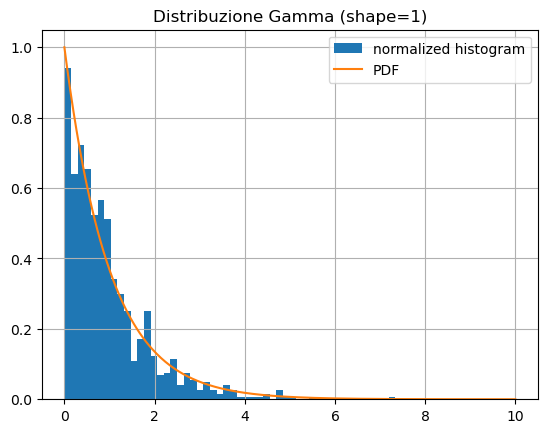

In [ ]:
#1.Distribuzione di probabilità

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

#distribuzione "congelata" con shape=1
dist = sp.stats.gamma(1)        

#campionamento: 1000 osservazioni
sample = dist.rvs(size=1000)

#istogramma normalizzato con PDF sovrapposta
x = np.linspace(0, 10, 300)

plt.hist(sample, bins=50, density=True, label='normalized histogram')
plt.plot(x, dist.pdf(x), label='PDF')
plt.title('Distribuzione Gamma (shape=1)')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
#stima parametro di forma con fit
# (stesso metodo degli appunti: sp.stats.norm.fit(sample))
a, loc, scale = sp.stats.gamma.fit(sample)

a, loc, scale

(np.float64(1.085642779242428),
 np.float64(0.0027373495862647495),
 np.float64(0.8772313377175696))

temp_max → MAE: 0.7720553267105025, RMSE: 0.8479022664866734
temp_min → MAE: 2.341008436102903, RMSE: 2.697276717042063


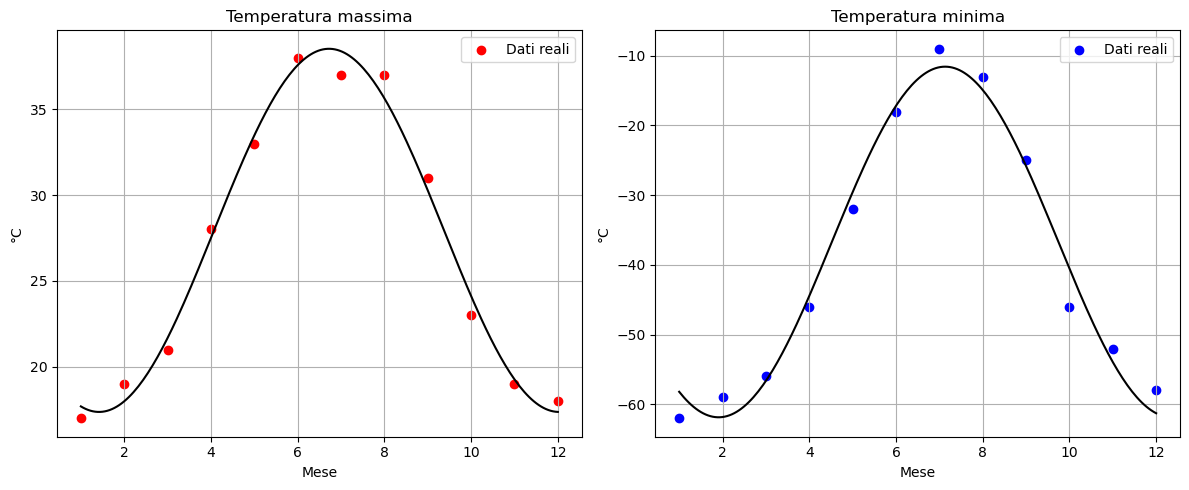

In [16]:
#2.Fitta i dati

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import math
 

temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
mesi = np.arange(1, 13)
 
#funzioni per calcolare MAE e RMSE 
def calculate_rmse(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    mse = sum((y_real[i] - y_pred[i]) ** 2 for i in range(len(y_real))) / len(y_real)
    return math.sqrt(mse)
 
def calculate_mae(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    errors = [abs(y_real[i] - y_pred[i]) for i in range(len(y_real))]
    return sum(errors) / len(errors)
 
#modello sinusoidale 
def sinusoidal(x, a, b, c, d):
    return a * np.sin(b * x + c) + d
 
x_dense = np.linspace(1, 12, 200)
 
#fitting e metriche per temp_max
p0 = [10, 2*np.pi/12, -np.pi/2, np.mean(temp_max)]
params_max, _ = sp.optimize.curve_fit(sinusoidal, mesi, temp_max, p0=p0, maxfev=10000)
y_max_sin = sinusoidal(x_dense, *params_max)
y_max_sin_pts = sinusoidal(mesi, *params_max)
 
mae_max = calculate_mae(temp_max.tolist(), y_max_sin_pts.tolist())
rmse_max = calculate_rmse(temp_max.tolist(), y_max_sin_pts.tolist())
print(f"temp_max → MAE: {mae_max}, RMSE: {rmse_max}")
 
#fitting per temp_min 
p0 = [10, 2*np.pi/12, -np.pi/2, np.mean(temp_min)]
params_min, _ = sp.optimize.curve_fit(sinusoidal, mesi, temp_min, p0=p0, maxfev=10000)
y_min_sin = sinusoidal(x_dense, *params_min)
y_min_sin_pts = sinusoidal(mesi, *params_min)
 
mae_min = calculate_mae(temp_min.tolist(), y_min_sin_pts.tolist())
rmse_min = calculate_rmse(temp_min.tolist(), y_min_sin_pts.tolist())
print(f"temp_min → MAE: {mae_min}, RMSE: {rmse_min}")
 
#plot 
plt.figure(figsize=(12, 5))
 
plt.subplot(1, 2, 1)
plt.scatter(mesi, temp_max, label="Dati reali", color="red")
plt.plot(x_dense, y_max_sin, color="black", linestyle="-")
plt.title("Temperatura massima")
plt.xlabel("Mese")
plt.ylabel("°C")
plt.legend()
plt.grid(True)
 
plt.subplot(1, 2, 2)
plt.scatter(mesi, temp_min, label="Dati reali", color="blue")
plt.plot(x_dense, y_min_sin, color="black", linestyle="-")
plt.title("Temperatura minima")
plt.xlabel("Mese")
plt.ylabel("°C")
plt.legend()
plt.grid(True)
 
plt.tight_layout()
plt.show()
 


Coefficiente angolare (m): -0.04121511996278613
Intercetta (q): 29.59985475616395
R-quadro: 0.7183433404897296
P-value: 9.380326537381565e-10
Errore standard: 0.004711833309637007
MAE: 2.605473485761069
RMSE: 3.1482072740002796


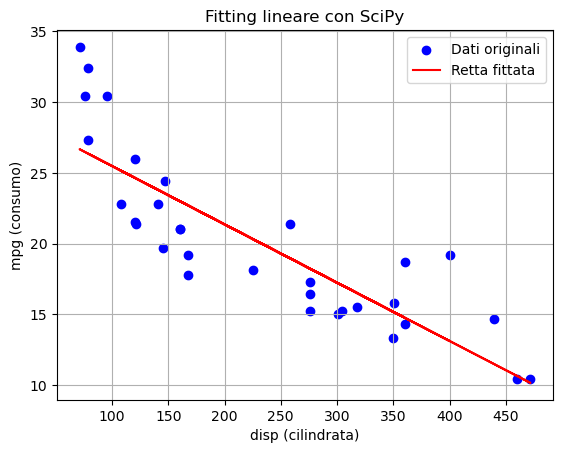

In [17]:
#3.Modello di regressione lineare dei seguenti dati

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import math
 
#carico dataset mtcars
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')
 
x = df['disp'].values
y = df['mpg'].values

#funzioni MAE e RMSE
def calculate_rmse(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    mse = sum((y_real[i] - y_pred[i]) ** 2 for i in range(len(y_real))) / len(y_real)
    return math.sqrt(mse)
 
def calculate_mae(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    errors = [abs(y_real[i] - y_pred[i]) for i in range(len(y_real))]
    return sum(errors) / len(errors)
 
#regressione lineare con scipy.stats.linregress 
slope, intercept, r_value, p_value, std_err = sp.stats.linregress(x, y)
 
#predizione valori fittati 
y_fit_sp = slope * x + intercept
 
# Output dei parametri
print(f"Coefficiente angolare (m): {slope}")
print(f"Intercetta (q): {intercept}")
print(f"R-quadro: {r_value**2}")
print(f"P-value: {p_value}")
print(f"Errore standard: {std_err}")
 
#MAE e RMSE 
mae = calculate_mae(y.tolist(), y_fit_sp.tolist())
rmse = calculate_rmse(y.tolist(), y_fit_sp.tolist())
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
 
# ── Plot (stesso stile degli appunti 7.2) ─────────────────────────
plt.scatter(x, y, label="Dati originali", color="blue")
plt.plot(x, y_fit_sp, label="Retta fittata", color="red")
plt.legend()
plt.xlabel("disp (cilindrata)")
plt.ylabel("mpg (consumo)")
plt.title("Fitting lineare con SciPy")
plt.grid(True)
plt.show()
